# Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset

In [5]:
data = load_breast_cancer()

X_full = pd.DataFrame(data.data, columns=data.feature_names)
Y = pd.Series(data.target)

print("Shape of dataset:", X_full.shape)
X_full.head()

Shape of dataset: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Data Understanding

In [4]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
X_full.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [6]:
Y.value_counts()

1    357
0    212
Name: count, dtype: int64

# Data Cleaning

In [7]:
# Check for missing values
X_full.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [8]:
# Check duplicates
X_full.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (30 Features Heatmap)

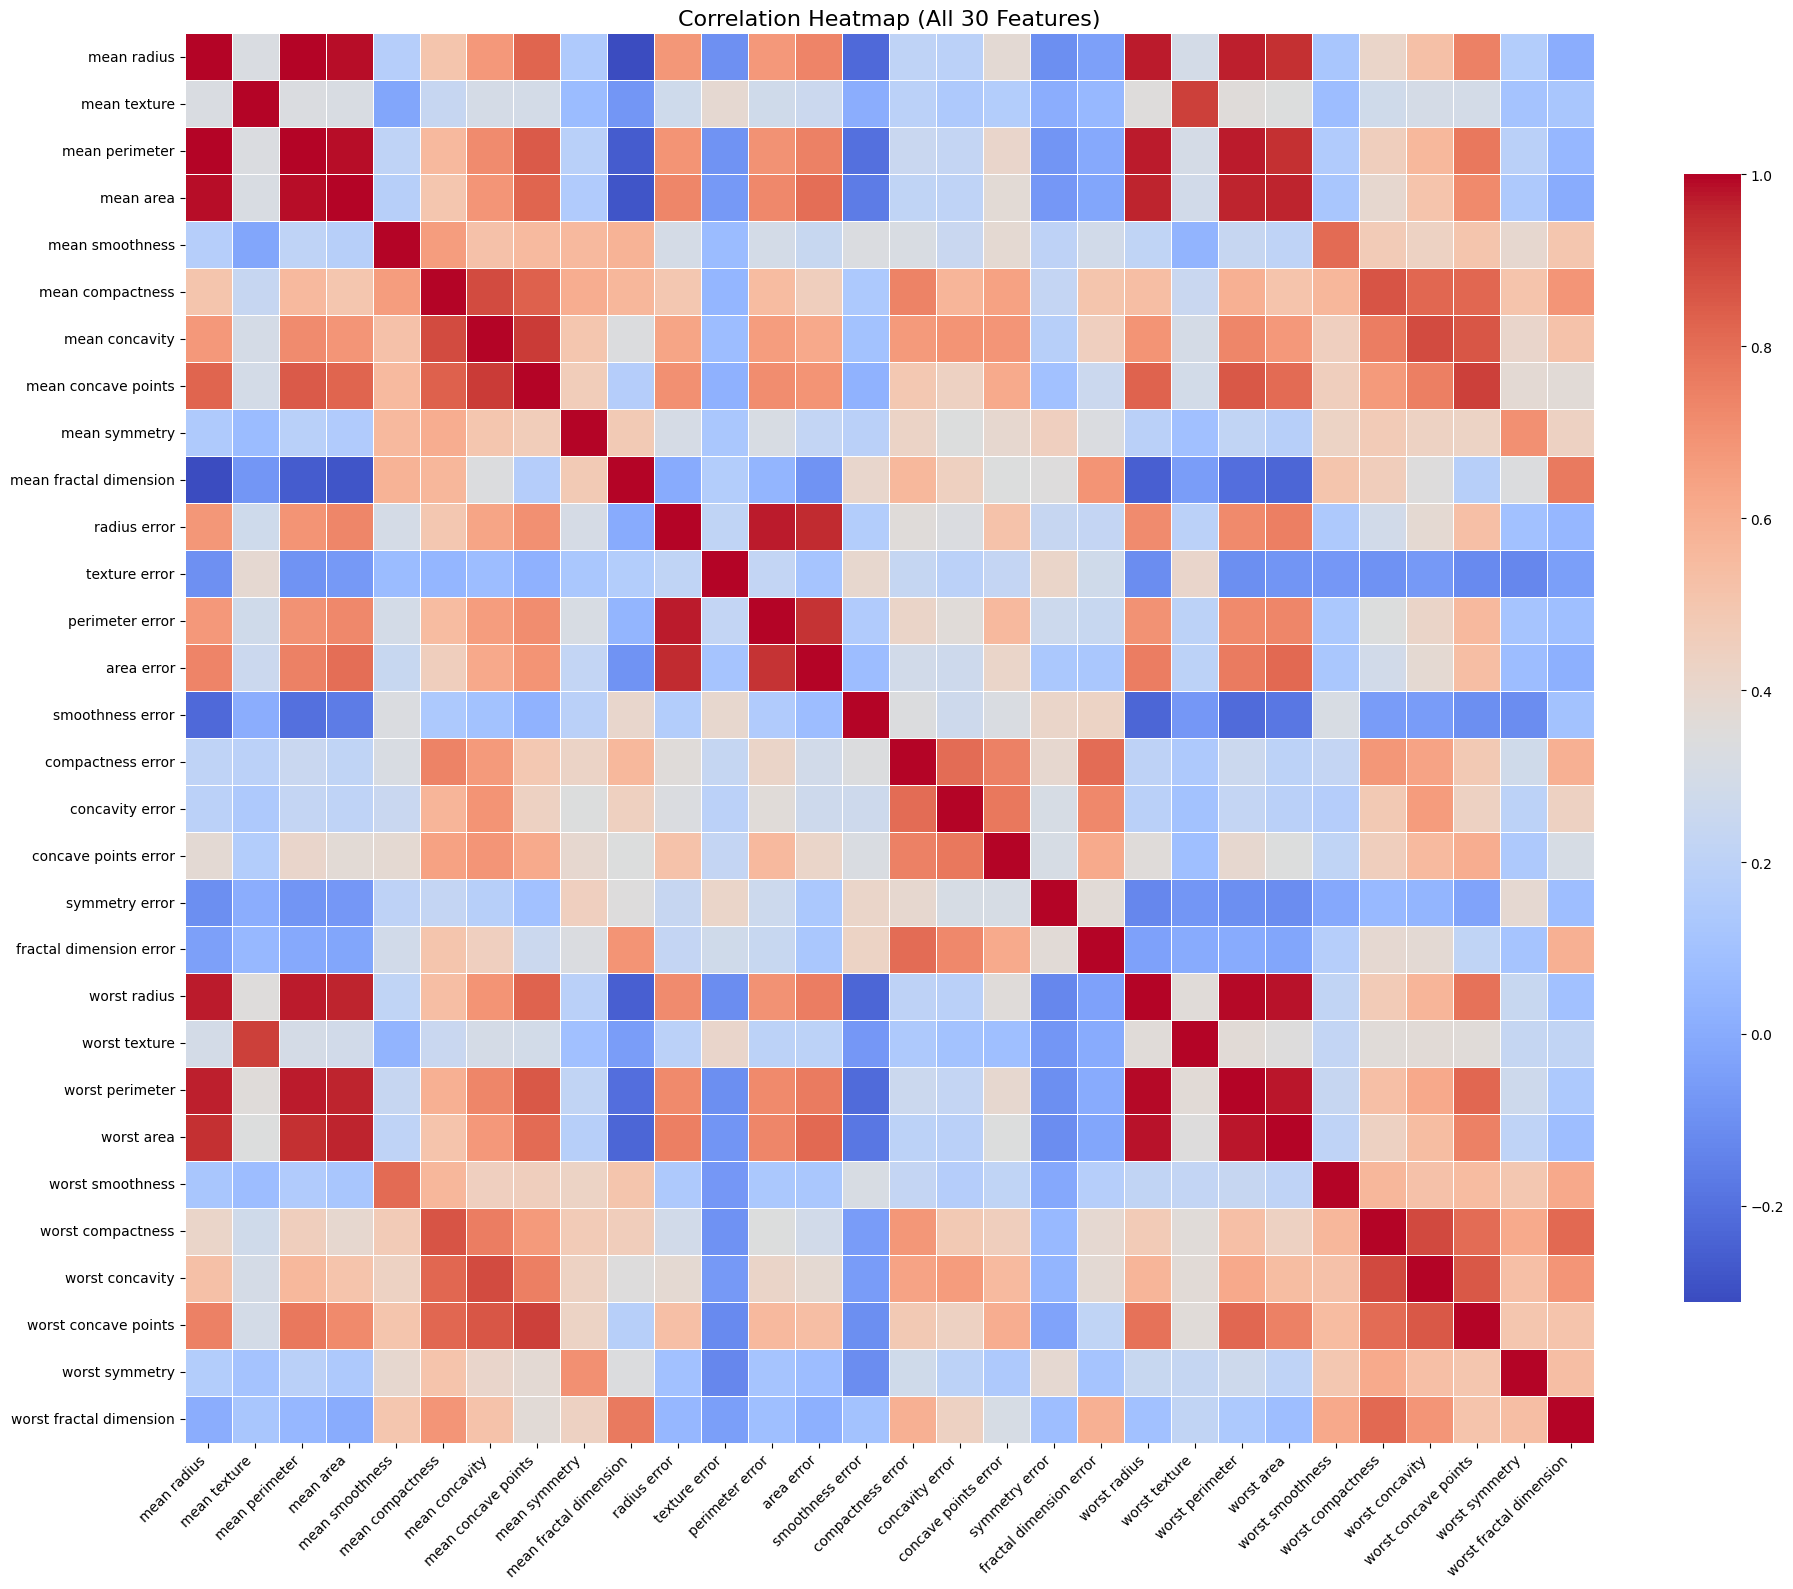

In [10]:
plt.figure(figsize=(20, 16))

sns.heatmap(
    X_full.corr(),
    cmap='coolwarm',       # better contrast
    annot=False,           # remove numbers (too crowded for 30 features)
    linewidths=0.5,        # grid lines for clarity
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (All 30 Features)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
correlation_with_target = X_full.corrwith(Y)

# Convert to DataFrame for better view
corr_df = pd.DataFrame(correlation_with_target, columns=['Correlation'])
corr_df = corr_df.sort_values(by='Correlation', ascending=False)

corr_df

,Correlation
smoothness error,0.067016
mean fractal dimension,0.012838
texture error,0.008303
symmetry error,0.006522
fractal dimension error,-0.077972
concavity error,-0.253730
compactness error,-0.292999
worst fractal dimension,-0.323872
mean symmetry,-0.330499
mean smoothness,-0.358560


In [12]:
top_15_features = corr_df.abs().sort_values(by='Correlation', ascending=False).head(15)
top_15_features

,Correlation
worst concave points,0.793566
worst perimeter,0.782914
mean concave points,0.776614
worst radius,0.776454
mean perimeter,0.742636
worst area,0.733825
mean radius,0.730029
mean area,0.708984
mean concavity,0.696360
worst concavity,0.659610


# Feature Selection (30 → 15)

In [6]:
selected_features = [
    'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity',
    'mean concave points', 'mean symmetry', 'radius error', 'area error', 'concavity error',
    'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points'
]

X = X_full[selected_features]

print("New shape after feature selection:", X.shape)
X.head()

New shape after feature selection: (569, 15)


,mean radius,mean texture,mean perimeter,mean area,mean concavity,mean concave points,mean symmetry,radius error,area error,concavity error,worst radius,worst texture,worst perimeter,worst area,worst concave points
0,17.99,10.38,122.80,1001.0,0.3001,0.14710,0.2419,1.0950,153.40,0.05373,25.38,17.33,184.60,2019.0,0.2654
1,20.57,17.77,132.90,1326.0,0.0869,0.07017,0.1812,0.5435,74.08,0.01860,24.99,23.41,158.80,1956.0,0.1860
2,19.69,21.25,130.00,1203.0,0.1974,0.12790,0.2069,0.7456,94.03,0.03832,23.57,25.53,152.50,1709.0,0.2430
3,11.42,20.38,77.58,386.1,0.2414,0.10520,0.2597,0.4956,27.23,0.05661,14.91,26.50,98.87,567.7,0.2575
4,20.29,14.34,135.10,1297.0,0.1980,0.10430,0.1809,0.7572,94.44,0.05688,22.54,16.67,152.20,1575.0,0.1625


# Correlation Heatmap (15 Features)

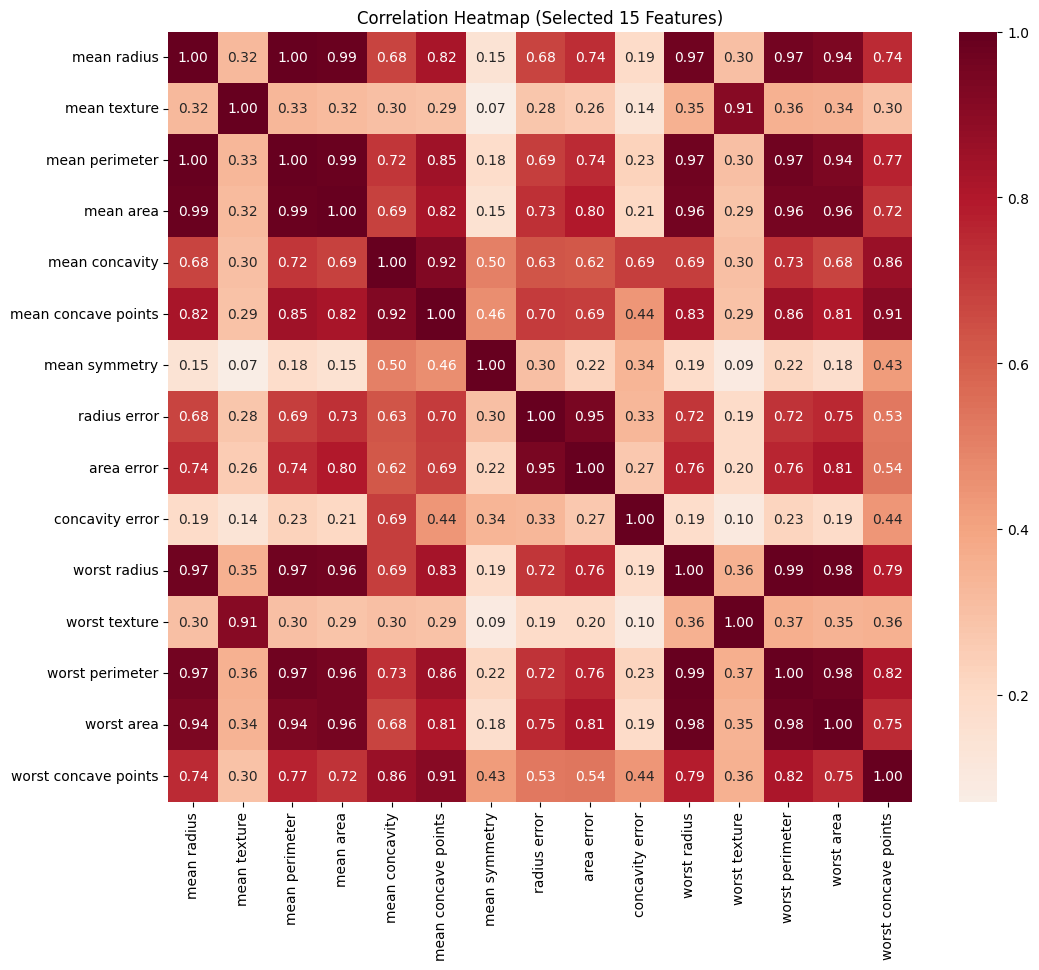

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Correlation Heatmap (Selected 15 Features)")
plt.show()

# Train-Test Split

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

print(X_train.shape, X_test.shape)

(455, 15) (114, 15)


# Model Training

# Logistic Regression

In [9]:
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train, Y_train)

LogisticRegression(max_iter=10000)

# Decision Tree

In [11]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier()

# K-Nearest Neighbors

In [12]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, Y_train)

KNeighborsClassifier()

# Model Evaluation

In [13]:
lr_acc = accuracy_score(Y_test, lr_model.predict(X_test))
dt_acc = accuracy_score(Y_test, dt_model.predict(X_test))
knn_acc = accuracy_score(Y_test, knn_model.predict(X_test))

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("KNN Accuracy:", knn_acc)

Logistic Regression Accuracy: 0.9298245614035088
Decision Tree Accuracy: 0.9035087719298246
KNN Accuracy: 0.9122807017543859


# Model Comparison Table

In [14]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy': [lr_acc, dt_acc, knn_acc]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.929825
1,Decision Tree,0.903509
2,KNN,0.912281


# Confusion Matrix (Best Model - Logistic Regression)

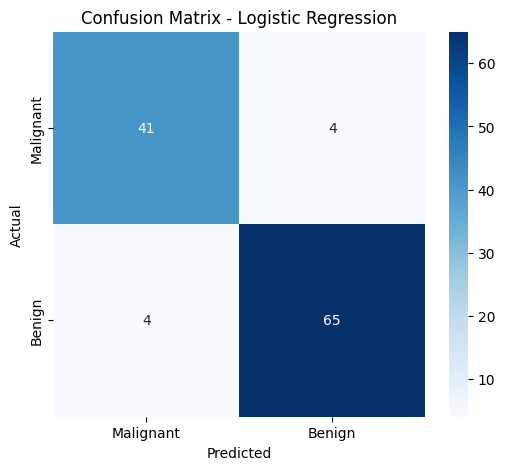

In [15]:
cm = confusion_matrix(Y_test, lr_model.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Classification Report

In [16]:
print(classification_report(Y_test, lr_model.predict(X_test),
      target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.91      0.91      0.91        45
      Benign       0.94      0.94      0.94        69

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



# Conclusion (Markdown Cell in Notebook)
Conclusion:

- Logistic Regression performed the best among all models.
- Feature selection reduced complexity while maintaining accuracy.
- The model was successfully deployed using Streamlit for real-time prediction.